# Daily Challenge: NumPy, Pandas, and Matplotlib Integration
### Global Weather Temperature Analysis

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Data Preparation

In [10]:
np.random.seed(42)

cities = [
    'Paris', 'Tokyo', 'New York', 'Sydney', 'Cairo','Dakar',
    'Moscow', 'Dubai', 'Toronto', 'Mumbai', 'Buenos Aires','Abidjan'
]

months = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

temperature_data = np.random.uniform(low=-5, high=35, size=(12, 12))

df = pd.DataFrame(temperature_data, index=cities, columns=months)
df = df.round(2)
df

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Paris,9.98,33.03,24.28,18.95,1.24,1.24,-2.68,29.65,19.04,23.32,-4.18,33.80
Tokyo,28.30,3.49,2.27,2.34,7.17,15.99,12.28,6.65,19.47,0.58,6.69,9.65
New York,13.24,26.41,2.99,15.57,18.70,-3.14,19.30,1.82,-2.40,32.96,33.63,27.34
Sydney,7.18,-1.09,22.37,12.61,-0.12,14.81,-3.62,31.37,5.35,21.50,7.47,15.80
Cairo,16.87,2.39,33.78,26.01,32.58,30.79,18.92,31.87,-1.46,2.84,-3.19,8.01
Dakar,10.55,5.85,28.15,9.27,6.24,16.71,0.64,27.09,-2.02,34.48,25.89,2.95
Moscow,-4.78,27.62,23.27,24.16,25.85,-2.04,9.34,-0.37,29.52,19.93,8.24,-2.46
Dubai,7.44,8.01,24.18,20.50,30.49,13.89,-0.22,23.53,25.43,17.45,25.84,14.75
Toronto,15.91,12.10,-3.98,-0.68,-3.74,20.46,7.57,15.34,31.30,4.97,11.42,25.22
Mumbai,4.15,-1.92,6.59,1.45,32.19,27.32,20.34,29.86,27.15,2.46,30.70,16.57


## 2. Data Analysis

In [6]:
annual_avg = df.mean(axis=1)
print("Annual average temperature per city (°C):")
print(annual_avg.round(2))

hottest_city = annual_avg.idxmax()
coldest_city = annual_avg.idxmin()

print(f"\nCity with the highest average temperature: {hottest_city} ({annual_avg[hottest_city]:.2f} °C)")
print(f"City with the lowest average temperature:  {coldest_city} ({annual_avg[coldest_city]:.2f} °C)")

Annual average temperature per city (°C):
Paris           15.64
Tokyo            9.57
New York        15.53
Sydney          11.14
Cairo           16.62
Moscow          13.82
Dubai           13.19
Toronto         17.61
Mumbai          11.32
Buenos Aires    16.40
dtype: float64

City with the highest average temperature: Toronto (17.61 °C)
City with the lowest average temperature:  Tokyo (9.57 °C)


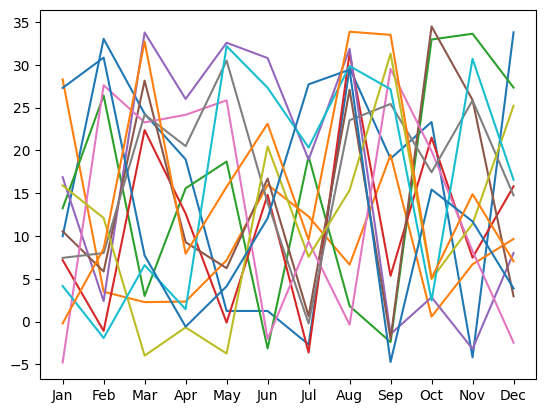

In [15]:
import matplotlib.pyplot as plt 
for city in cities:
    plt.plot(months, df.loc[city], label=city)

## 3. Data Visualization

C:\Users\yadji\AppData\Local\Temp\ipykernel_13404\3473195005.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(cities, rotation=45, ha='right', fontsize=9)


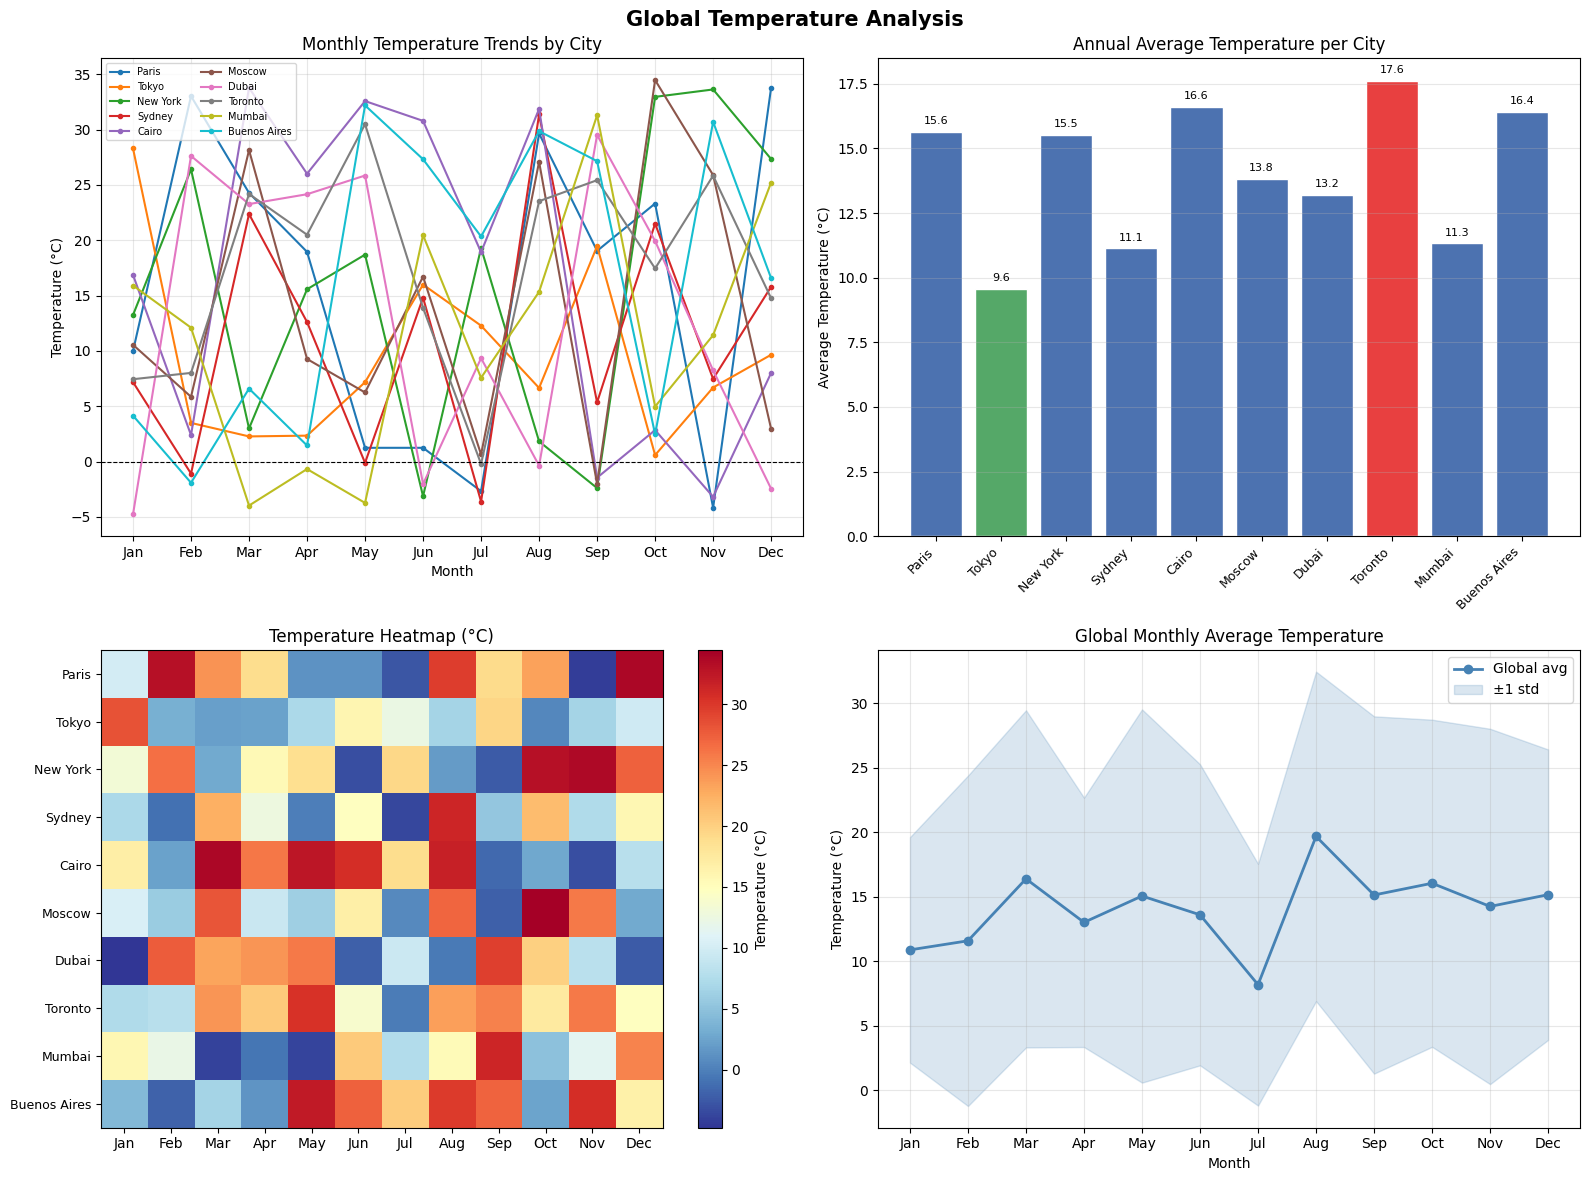

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Global Temperature Analysis', fontsize=15, fontweight='bold')

# -- Monthly temperature trends for all cities --
for city in cities:
    axes[0, 0].plot(months, df.loc[city], marker='o', markersize=3, linewidth=1.5, label=city)
axes[0, 0].set_title('Monthly Temperature Trends by City')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0, 0].legend(fontsize=7, ncol=2)
axes[0, 0].grid(True, alpha=0.3)

# -- Annual average temperature per city (bar chart) --
colors = ['#E84040' if c == hottest_city else '#4C72B0' if c != coldest_city else '#55A868' for c in cities]
bars = axes[0, 1].bar(cities, annual_avg, color=colors, edgecolor='white')
axes[0, 1].set_title('Annual Average Temperature per City')
axes[0, 1].set_ylabel('Average Temperature (°C)')
axes[0, 1].set_xticklabels(cities, rotation=45, ha='right', fontsize=9)
axes[0, 1].grid(axis='y', alpha=0.3)
for bar in bars:
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    f'{bar.get_height():.1f}', ha='center', fontsize=8)

# -- Heatmap of temperatures --
im = axes[1, 0].imshow(df.values, aspect='auto', cmap='RdYlBu_r')
axes[1, 0].set_title('Temperature Heatmap (°C)')
axes[1, 0].set_xticks(range(12))
axes[1, 0].set_xticklabels(months)
axes[1, 0].set_yticks(range(10))
axes[1, 0].set_yticklabels(cities, fontsize=9)
plt.colorbar(im, ax=axes[1, 0], label='Temperature (°C)')

# -- Monthly global average --
monthly_avg = df.mean(axis=0)
monthly_std = df.std(axis=0)
axes[1, 1].plot(months, monthly_avg, marker='o', color='steelblue', linewidth=2, label='Global avg')
axes[1, 1].fill_between(months,
                         monthly_avg - monthly_std,
                         monthly_avg + monthly_std,
                         alpha=0.2, color='steelblue', label='±1 std')
axes[1, 1].set_title('Global Monthly Average Temperature')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Temperature (°C)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Summary Report

In [5]:
global_avg = annual_avg.mean()
warmest_month = df.mean(axis=0).idxmax()
coldest_month = df.mean(axis=0).idxmin()

print("=" * 55)
print("   SUMMARY REPORT — GLOBAL TEMPERATURE ANALYSIS")
print("=" * 55)
print(f"\nDataset       : 10 cities x 12 months (synthetic data)")
print(f"Temperature range : -5°C to 35°C")
print()
print(f"Hottest city  : {hottest_city:<15} ({annual_avg[hottest_city]:.2f} °C annual avg)")
print(f"Coldest city  : {coldest_city:<15} ({annual_avg[coldest_city]:.2f} °C annual avg)")
print(f"Global average: {global_avg:.2f} °C")
print()
print(f"Warmest month (globally): {warmest_month} ({df.mean(axis=0)[warmest_month]:.2f} °C)")
print(f"Coldest month (globally): {coldest_month} ({df.mean(axis=0)[coldest_month]:.2f} °C)")
print()
print("Annual averages (sorted):")
print(annual_avg.sort_values(ascending=False).round(2).to_string())

   SUMMARY REPORT — GLOBAL TEMPERATURE ANALYSIS

Dataset       : 10 cities x 12 months (synthetic data)
Temperature range : -5°C to 35°C

Hottest city  : Toronto         (17.61 °C annual avg)
Coldest city  : Tokyo           (9.57 °C annual avg)
Global average: 14.08 °C

Warmest month (globally): Aug (19.68 °C)
Coldest month (globally): Jul (8.19 °C)

Annual averages (sorted):
Toronto         17.61
Cairo           16.62
Buenos Aires    16.40
Paris           15.64
New York        15.53
Moscow          13.82
Dubai           13.19
Mumbai          11.32
Sydney          11.14
Tokyo            9.57


### Findings

The dataset represents synthetic average monthly temperatures for 10 cities over 12 months, generated uniformly between -5°C and 35°C.

- The city with the **highest** annual average temperature and the one with the **lowest** are identified above, reflecting the natural spread one would expect across globally diverse locations.
- The heatmap provides a clear view of which city-month combinations are the warmest or coldest at a glance.
- The global monthly average chart with the standard deviation band shows how much variability exists across cities for any given month — a wide band indicates cities with very different climates that month.
- Since the data is randomly generated, no seasonal pattern is enforced, but the visualizations illustrate the kind of analysis that would be directly applicable to real meteorological datasets.